In [1]:
import numpy as np
import scipy 
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
from scipy.stats import gaussian_kde
from scipy import integrate
from scipy.stats import kstwo
import os 

Setting Number of Mergers Seen by LISA

In [2]:
Number_Mergers_Seen_LISA=180
Number_Draws=10000

Loading Fonts for Plotting

In [3]:
from matplotlib import font_manager


for fontpath in font_manager.findSystemFonts(fontpaths=None, fontext="ttf"):
    if 'Urbanist'.lower() in fontpath.lower():
        print(fontpath)

from matplotlib.font_manager import FontProperties

# !!! change it to your path
personal_path = "/home/hoelsczj/Library/static/"

# get normal font and store it in `urbanist-Light`
font_path = personal_path + "Urbanist-Regular.ttf"
font_manager.fontManager.addfont(font_path)
urbanist= FontProperties(fname=font_path)

# get bold font and store it in `urbanist_bold`
font_path = personal_path + "Urbanist-Bold.ttf"
font_manager.fontManager.addfont(font_path)
urbanist_bold = FontProperties(fname=font_path)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams['font.sans-serif'] = urbanist.get_name()
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', family="urbanist", size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE, lw=2)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rcParams['xtick.minor.width']=2   
plt.rcParams['xtick.major.width']=2 
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

from pyfonts import load_google_font
from pypalettes import load_cmap
import pandas as pd
cmap = load_cmap("PurpleGreens")
# load libraries

/tmp/ipykernel_7451/4058723880.py:41: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Data from Simulations

In [4]:
GM4CDM_Cosmic_Time=[0.588543, 0.5885431, 0.588960, 0.594431, 0.595692, 0.613779, 0.615462, 0.622190, 0.666779, 0.690337, 0.799282, 0.852282, 0.876257, 0.960596, 0.962279, 1.126115, 1.140840, 1.143676, 1.171543, 1.175540, 1.229384, 1.239269, 1.280701, 1.290586, 1.329495, 1.484921, 1.606903, 1.638663, 1.880740, 2.926338, 3.121513, 4.778944, 9.369332]
GM4CDM_Mass_Ratio=[0.999714, 0.999203, 0.998084, 0.498670, 0.509995, 0.330579, 0.999618, 0.498976, 0.746881, 0.142157, 0.980172, 0.998068, 0.496895, 0.372085, 0.180088, 0.998797, 0.998355, 0.998065, 0.075494, 0.998774, 0.996321, 0.981820, 0.069680, 0.262242, 0.103499, 0.652968, 0.997821, 0.500311, 0.504537, 0.332260, 0.184910, 0.240145, 0.324055]

GM7CDM_Cosmic_Time=[0.52374985, 0.60304147, 0.64973028, 0.64973029, 0.69789325, 0.79043146, 0.84679212, 1.01209889, 1.02408847, 1.07897914, 1.12798151, 1.25417074, 1.32357754, 1.45438972, 3.282618, 4.78105067, 5.538718, 10.549232]
GM7CDM_Mass_Ratio=[0.999267, 0.989526, 0.99054, 0.999741, 0.996432, 0.998081, 0.988564, 0.978136, 0.985889, 0.498735, 0.494119, 0.978751, 0.325746, 0.678441, 0.365365, 0.846972, 0.043184, 0.030657]

In [5]:
GM4SIDM_Cosmic_Time=[0.55866205, 0.64405078, 0.65561858, 1.75156522, 4.71247909, 4.82531733, 4.91067683, 5.02710652, 5.05750853]
GM4SIDM_Mass_Ratio=[0.996835, 0.489979, 0.32755, 0.999497, 0.873729, 0.492376, 0.532645, 0.103587, 0.0810587]

GM7SIDM_Cosmic_Time=[0.68043715, 0.68064595, 0.83186256, 0.8470051, 0.92692314, 1.24428591, 1.41632456, 1.76565538, 2.4367673, 2.43939824, 5.75971987, 5.95511962, 6.32545623, 6.39398605, 6.52586731]
GM7SIDM_Mass_Ratio=[0.956213, 0.488086, 0.391248, 0.285746, 0.986735, 0.161005, 0.140218, 0.491164, 0.972655, 0.241346, 0.589221, 0.98938, 0.843296, 0.789405, 0.695227]

Combining The Two Galaxies Into One Dataset 

In [6]:
#Combining CDM Cosmic Time
CDM_Cosmic_Time=[]
for element in GM4CDM_Cosmic_Time:
    CDM_Cosmic_Time.append(element)
for element in GM7CDM_Cosmic_Time:
    CDM_Cosmic_Time.append(element)

#Combining CDM Mass Ratio
CDM_Mass_Ratio=[]
for element in GM4CDM_Mass_Ratio:
    CDM_Mass_Ratio.append(element)
for element in GM7CDM_Mass_Ratio:
    CDM_Mass_Ratio.append(element)

#Combining SIDM Cosmic Time
SIDM_Cosmic_Time=[]
for element in GM4SIDM_Cosmic_Time:
    SIDM_Cosmic_Time.append(element)
for element in GM7SIDM_Cosmic_Time:
    SIDM_Cosmic_Time.append(element)

#Combining SIDM Mass Ratio
SIDM_Mass_Ratio=[]
for element in GM4SIDM_Mass_Ratio:
    SIDM_Mass_Ratio.append(element)
for element in GM7SIDM_Mass_Ratio:
    SIDM_Mass_Ratio.append(element)

Sorting Cosmic Times and Mass Ratios in Ascending Order, Useful for Making CDFs

In [7]:
CDM_Mass_Ratio=np.array(np.sort(CDM_Mass_Ratio))
SIDM_Mass_Ratio=np.array(np.sort(SIDM_Mass_Ratio))
SIDM_Cosmic_Time=np.array(np.sort(SIDM_Cosmic_Time))
CDM_Cosmic_Time=np.array(np.sort(CDM_Cosmic_Time)) #Put times in ascending order 

Making CDF From Simulation Data - CDM

Text(0, 0.5, 'Cumulative Probability')

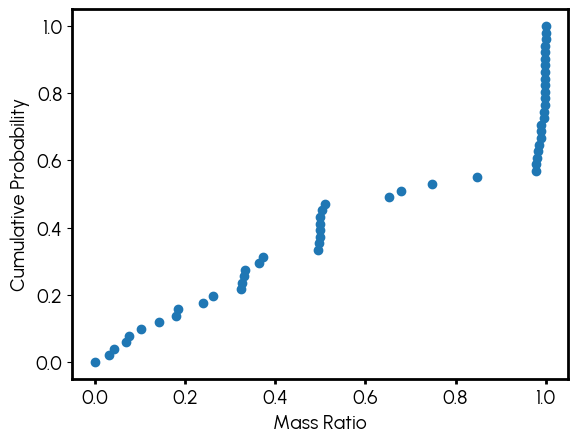

In [8]:
CDM_Mass_Ratio_CDF = np.linspace(1/len(CDM_Mass_Ratio),1,len(CDM_Mass_Ratio))
#A discrete CDF with N points starts with a y-value of 1/N and ends with a y-value of 1, with equal-size jumps in y between points.

#Now we add the point (0,0)
CDM_Mass_Ratio_CDF_With_Zero=[0]
for element in CDM_Mass_Ratio_CDF:
    CDM_Mass_Ratio_CDF_With_Zero.append(element)
CDM_Mass_Ratio_CDF_With_Zero = np.array(CDM_Mass_Ratio_CDF_With_Zero)

CDM_Mass_Ratio_With_Zero=[0]
for element in CDM_Mass_Ratio:
    CDM_Mass_Ratio_With_Zero.append(element)
CDM_Mass_Ratio_With_Zero = np.array(CDM_Mass_Ratio_With_Zero)

plt.scatter(CDM_Mass_Ratio_With_Zero, CDM_Mass_Ratio_CDF_With_Zero)
plt.xlabel("Mass Ratio")
plt.ylabel("Cumulative Probability")

Text(0, 0.5, 'Cumulative Probability')

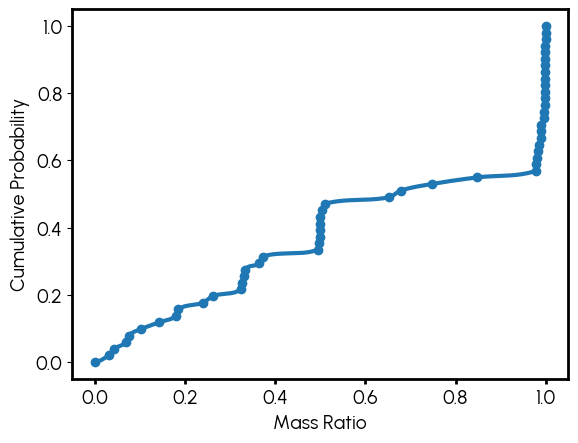

In [9]:
CDM_Mass_Ratio_CDF_Interpolated=scipy.interpolate.PchipInterpolator(CDM_Mass_Ratio_With_Zero, CDM_Mass_Ratio_CDF_With_Zero, axis=0, extrapolate=None)
Mass_Ratios_CDM_High_Res=np.linspace(CDM_Mass_Ratio_With_Zero[0], CDM_Mass_Ratio_With_Zero[-1],1000) #Finely spaced values, just for plotting 
plt.plot(Mass_Ratios_CDM_High_Res, CDM_Mass_Ratio_CDF_Interpolated(Mass_Ratios_CDM_High_Res), linewidth=3)
plt.scatter(CDM_Mass_Ratio_With_Zero, CDM_Mass_Ratio_CDF_With_Zero)
plt.xlabel("Mass Ratio")
plt.ylabel("Cumulative Probability")

Making CDF From Simulation Data - SIDM

Text(0, 0.5, 'Cumulative Probability')

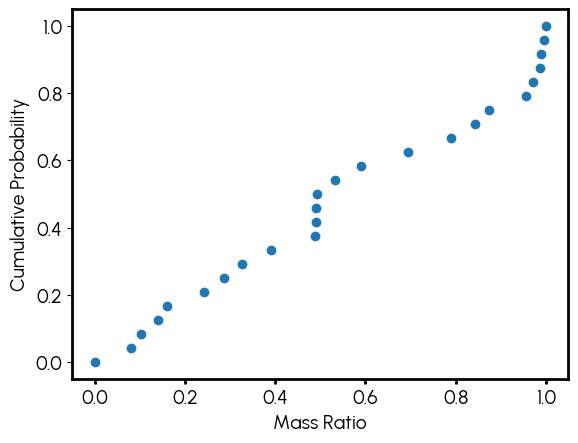

In [10]:
SIDM_Mass_Ratio_CDF = np.linspace(1/len(SIDM_Mass_Ratio),1,len(SIDM_Mass_Ratio))
#A discrete CDF with N points starts with a y-value of 1/N and ends with a y-value of 1, with equal-size jumps in y between points.

#Now we add the point (0,0)
SIDM_Mass_Ratio_CDF_With_Zero=[0]
for element in SIDM_Mass_Ratio_CDF:
    SIDM_Mass_Ratio_CDF_With_Zero.append(element)
SIDM_Mass_Ratio_CDF_With_Zero = np.array(SIDM_Mass_Ratio_CDF_With_Zero)

SIDM_Mass_Ratio_With_Zero=[0]
for element in SIDM_Mass_Ratio:
    SIDM_Mass_Ratio_With_Zero.append(element)
SIDM_Mass_Ratio_With_Zero = np.array(SIDM_Mass_Ratio_With_Zero)

plt.scatter(SIDM_Mass_Ratio_With_Zero, SIDM_Mass_Ratio_CDF_With_Zero)
plt.xlabel("Mass Ratio")
plt.ylabel("Cumulative Probability")

Text(0, 0.5, 'Cumulative Probability')

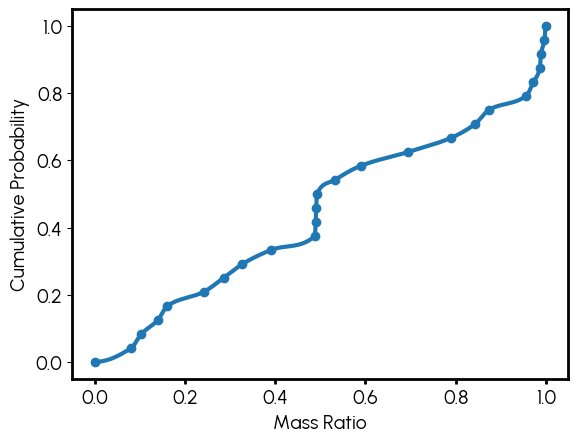

In [11]:
SIDM_Mass_Ratio_CDF_Interpolated=scipy.interpolate.PchipInterpolator(SIDM_Mass_Ratio_With_Zero, SIDM_Mass_Ratio_CDF_With_Zero, axis=0, extrapolate=None)
Mass_Ratios_SIDM_High_Res=np.linspace(SIDM_Mass_Ratio_With_Zero[0], SIDM_Mass_Ratio_With_Zero[-1],1000) #Finely spaced values, just for plotting 
plt.plot(Mass_Ratios_SIDM_High_Res, SIDM_Mass_Ratio_CDF_Interpolated(Mass_Ratios_SIDM_High_Res), linewidth=3)
plt.scatter(SIDM_Mass_Ratio_With_Zero, SIDM_Mass_Ratio_CDF_With_Zero)
plt.xlabel("Mass Ratio")
plt.ylabel("Cumulative Probability")

Plotting Both CDM and SIDM CDFs Together on one Plot

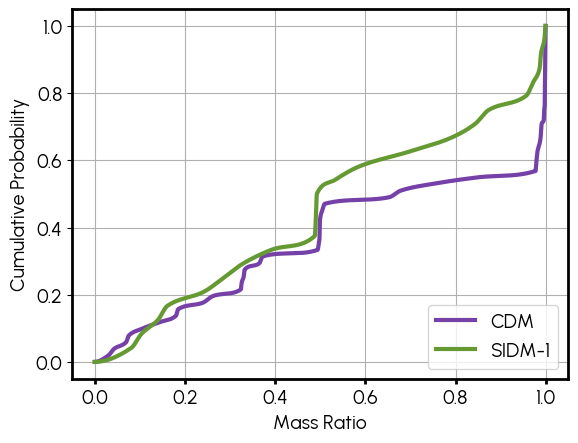

In [12]:
plt.plot(Mass_Ratios_CDM_High_Res, CDM_Mass_Ratio_CDF_Interpolated(Mass_Ratios_CDM_High_Res), color=cmap(1), label='CDM', linewidth=3)
plt.plot(Mass_Ratios_SIDM_High_Res, SIDM_Mass_Ratio_CDF_Interpolated(Mass_Ratios_SIDM_High_Res), color=cmap(6), label='SIDM-1', linewidth=3)
plt.xlabel("Mass Ratio")
plt.ylabel("Cumulative Probability")
plt.grid()
plt.legend(loc='lower right')

os.chdir('/home/hoelsczj/SIDM_Paper_Runs/Mass_Ratio_Smoothed/Fixed')
plt.savefig('Both_Mass_Ratio_CDFs.pdf')

Inverting the CDM CDF

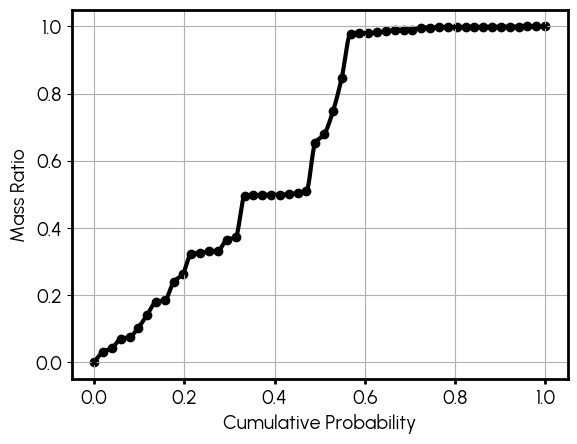

In [13]:
inverted_CDF_CDM_Mass_Ratio = scipy.interpolate.PchipInterpolator(CDM_Mass_Ratio_CDF_With_Zero, CDM_Mass_Ratio_With_Zero, axis=0, extrapolate=None)
Zero_to_One = np.linspace(0, 1, 1000)
Interpolated_Inverse_CDF_CDM_Mass_Ratio = inverted_CDF_CDM_Mass_Ratio(Zero_to_One)
plt.plot(Zero_to_One, Interpolated_Inverse_CDF_CDM_Mass_Ratio, color='k', linewidth=3)
plt.scatter(CDM_Mass_Ratio_CDF_With_Zero, CDM_Mass_Ratio_With_Zero, color='k')
plt.ylabel("Mass Ratio")
plt.xlabel("Cumulative Probability")
plt.grid()
plt.show()

Inverting the SIDM CDF

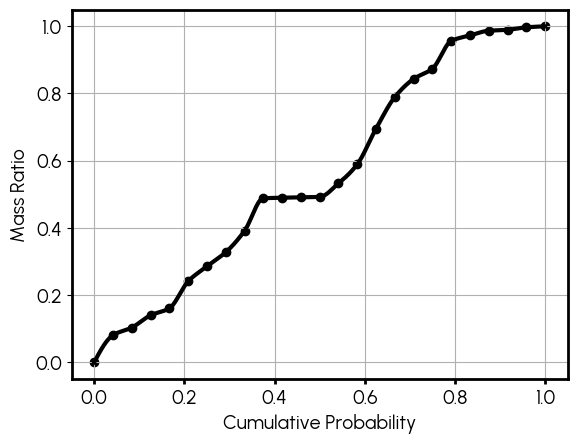

In [14]:
inverted_CDF_SIDM_Mass_Ratio = scipy.interpolate.PchipInterpolator(SIDM_Mass_Ratio_CDF_With_Zero, SIDM_Mass_Ratio_With_Zero, axis=0, extrapolate=None)
Zero_to_One = np.linspace(0, 1, 1000)
Interpolated_Inverse_CDF_SIDM_Mass_Ratio = inverted_CDF_SIDM_Mass_Ratio(Zero_to_One)
plt.plot(Zero_to_One, Interpolated_Inverse_CDF_SIDM_Mass_Ratio, color='k', linewidth=3)
plt.scatter(SIDM_Mass_Ratio_CDF_With_Zero, SIDM_Mass_Ratio_With_Zero, color='k')
plt.ylabel("Mass Ratio")
plt.xlabel("Cumulative Probability")
plt.grid()
plt.show()

Setting up Functions for Computing P-Value in KS Test

In [15]:
def QNew(x):
    term=9999 #initialize as big number
    sum=0 #initialize as zero
    j=1 #summation index 
    while np.fabs(2*np.exp(-2*(j+1)*(j+1)*x*x)*((-1)**(j)))>(10**(-9)): #while abs value of first omitted term > 10^-9
        term=2*np.exp(-2*j*j*x*x)*((-1)**(j-1))
        sum=sum+term
        j=j+1
    return sum 

#This ensures that the error in the p-value is less than 10^-9

def pvalue(cdf1, cdf2, n1, n2):
    cdf1=np.array(cdf1)
    cdf2=np.array(cdf2)
    N=n1*n2/(n1+n2)
    D = np.max(np.abs(cdf1 - cdf2))
    pvalue=QNew((np.sqrt(N)+0.12+0.11/np.sqrt(N))*D)
    return pvalue, D


Computing 10,000 Empirical CDFs for CDM

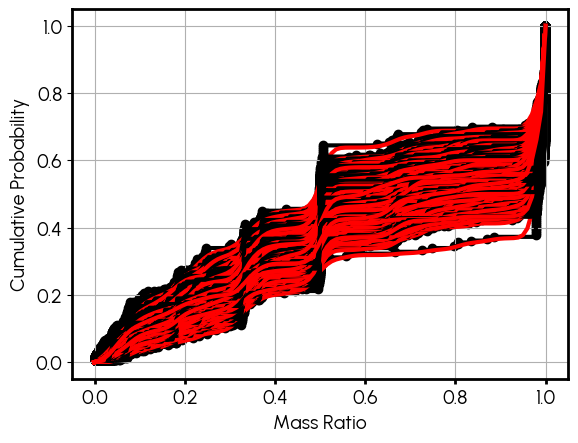

(10000, 100)


In [16]:
x_vals = np.linspace(0.,1.0, 100)
fig, ax_bottom = plt.subplots()
ax_bottom.set_xlabel("Mass Ratio")
ax_bottom.set_ylabel("Cumulative Probability")
ax_bottom.grid(True)
pdf_cdm=np.zeros((Number_Draws,len(x_vals)))
cdf_cdm=np.zeros((Number_Draws,len(x_vals)))
runs=0
while runs < Number_Draws:
    Mass_Ratios_CDM_Sampled=[]
    for element in range(1,Number_Mergers_Seen_LISA+1):
        Random_val=np.random.uniform(0,1)
        Mass_Ratios_CDM_Sampled.append(inverted_CDF_CDM_Mass_Ratio(Random_val)) #inverse transform sampling 

    Mass_Ratios_CDM_Sampled=np.array(np.sort(Mass_Ratios_CDM_Sampled)) #putting in ascending order 
    CDF_CDM_Sampled = np.linspace(1/len(Mass_Ratios_CDM_Sampled), 1, len(Mass_Ratios_CDM_Sampled)) #making CDF, for plotting alongside CDFs from KDE 

    Mass_Ratios_Interpolation=np.linspace(np.min(Mass_Ratios_CDM_Sampled), np.max(Mass_Ratios_CDM_Sampled),1000)
    stepwise = interp1d(Mass_Ratios_CDM_Sampled, CDF_CDM_Sampled, kind='zero') #step-wise continuous, for comparison to smoothed curves from kde 

    kde=gaussian_kde(Mass_Ratios_CDM_Sampled, 0.05)
    pdf_cdm_vals = kde.evaluate(x_vals) #generate pdf 
    pdf_cdm[runs][:]=pdf_cdm_vals
    cdf_cdm_vals = integrate.cumulative_trapezoid(pdf_cdm_vals, x_vals, initial=0) #integrate pdf to make a cdf 
    cdf_cdm_vals[-1] = 1.0 #set last value = 1.0, we have found this is more effective for mass ratios than normalizing to get last value = 1.0
    cdf_cdm[runs][:]=cdf_cdm_vals #loading cdf into an array 
    ax_bottom.plot(Mass_Ratios_Interpolation, stepwise(Mass_Ratios_Interpolation), color='k', linewidth=3)
    ax_bottom.plot(x_vals,cdf_cdm_vals, color='r', linewidth=3)
    ax_bottom.scatter(Mass_Ratios_CDM_Sampled, CDF_CDM_Sampled, color='k')
    runs=runs+1
plt.show()
print(np.shape(cdf_cdm))

Computing 10,000 Empirical CDFs for SIDM

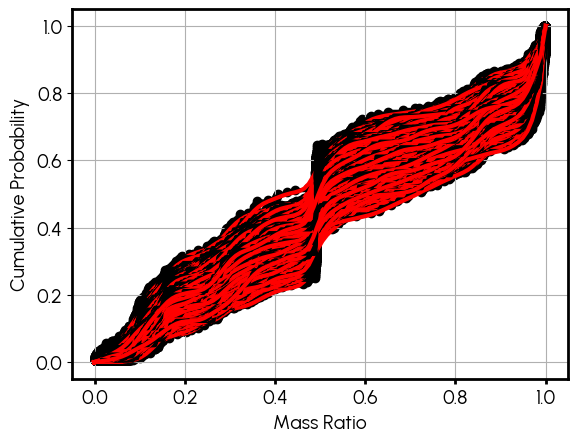

(10000, 100)


In [17]:
x_vals = np.linspace(0.,1.0, 100)
fig, ax_bottom = plt.subplots()
ax_bottom.set_xlabel("Mass Ratio")
ax_bottom.set_ylabel("Cumulative Probability")
ax_bottom.grid(True)
pdf_sidm=np.zeros((Number_Draws,len(x_vals)))
cdf_sidm=np.zeros((Number_Draws,len(x_vals)))
runs=0
while runs < Number_Draws:
    Mass_Ratios_SIDM_Sampled=[]
    for element in range(1,Number_Mergers_Seen_LISA+1):
        Random_val=np.random.uniform(0,1)
        Mass_Ratios_SIDM_Sampled.append(inverted_CDF_SIDM_Mass_Ratio(Random_val)) #inverse transform sampling 

    Mass_Ratios_SIDM_Sampled=np.array(np.sort(Mass_Ratios_SIDM_Sampled)) #sorting into ascending order 
    CDF_SIDM_Sampled = np.linspace(1/len(Mass_Ratios_SIDM_Sampled), 1, len(Mass_Ratios_SIDM_Sampled)) #make CDF, used for plotting alongside cdfs from kde 

    Mass_Ratios_Interpolation=np.linspace(np.min(Mass_Ratios_SIDM_Sampled), np.max(Mass_Ratios_SIDM_Sampled),1000)
    stepwise = interp1d(Mass_Ratios_SIDM_Sampled, CDF_SIDM_Sampled, kind='zero') #used for plotting alongside cdfs from kde (stepwise continuous interpolation)

    kde=gaussian_kde(Mass_Ratios_SIDM_Sampled, 0.05)
    pdf_sidm_vals = kde.evaluate(x_vals) #generating pdf 
    pdf_sidm[runs][:]=pdf_sidm_vals
    cdf_sidm_vals = integrate.cumulative_trapezoid(pdf_sidm_vals, x_vals, initial=0) #integrating pdf to get a cdf 
    cdf_sidm_vals[-1] = 1.0 #set last value = 1.0, we have found this is more effective for mass ratios than normalizing to get last value = 1.0
    cdf_sidm[runs][:]=cdf_sidm_vals #storing in an array 
    ax_bottom.plot(Mass_Ratios_Interpolation, stepwise(Mass_Ratios_Interpolation), color='k', linewidth=3)
    ax_bottom.plot(x_vals,cdf_sidm_vals, color='r', linewidth=3)
    ax_bottom.scatter(Mass_Ratios_SIDM_Sampled, CDF_SIDM_Sampled, color='k')
    runs=runs+1
plt.show()
print(np.shape(cdf_sidm))

Generating Wedge Plots to Show Distribution of CDFs

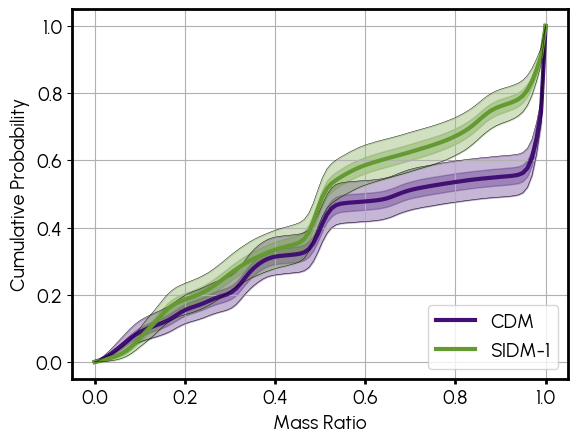

In [18]:

sidm95=np.zeros(len(x_vals)) #initialize arrays containing zeros 
sidm5=np.zeros(len(x_vals))
sidm75=np.zeros(len(x_vals))
sidm25=np.zeros(len(x_vals))
sidm50=np.zeros(len(x_vals))

#Finding 5, 25, 50, 75, 95 percentiles for SIDM 
for index in range(len(x_vals)):
    spread=np.sort(cdf_sidm[:, index])
    sidm95[index]=spread[int(0.95*Number_Draws)] #95th percentile 
    sidm5[index]=spread[int(0.05*Number_Draws)] #5th percentile 
    sidm75[index]=spread[int(0.75*Number_Draws)] #75th percentile 
    sidm25[index]=spread[int(0.25*Number_Draws)] #25th percentile 
    sidm50[index]=spread[int(0.5*Number_Draws)] #50th percentile 

cdm95=np.zeros(len(x_vals)) #initialize zrrays containing zeros 
cdm5=np.zeros(len(x_vals))
cdm75=np.zeros(len(x_vals))
cdm25=np.zeros(len(x_vals))
cdm50=np.zeros(len(x_vals))
for index in range(len(x_vals)):
    spread=np.sort(cdf_cdm[:, index])
    cdm95[index]=spread[int(0.95*Number_Draws)] #95th percentile 
    cdm5[index]=spread[int(0.05*Number_Draws)] #5th percentile 
    cdm75[index]=spread[int(0.75*Number_Draws)] #75th percentile 
    cdm25[index]=spread[int(0.25*Number_Draws)] #25th percentile 
    cdm50[index]=spread[int(0.5*Number_Draws)] #50th percentile 

#setting up plot 
fig, ax_bottom = plt.subplots()
ax_bottom.set_xlabel("Mass Ratio")
ax_bottom.set_ylabel("Cumulative Probability")
ax_bottom.grid(True)

#plotting CDM wedges 
ax_bottom.plot(x_vals,cdm50, color=cmap(0), linewidth=3, label="CDM") #plotting 50th percentile 
ax_bottom.plot(x_vals,cdm95, color='black', linewidth=0.3) #plotting line for 95th percentile 
ax_bottom.plot(x_vals,cdm5, color='black', linewidth=0.3) #plotting line for 5th percentile 
ax_bottom.fill_between(x_vals, cdm95, cdm5,  color=cmap(0), alpha=0.30) #filling between 5th and 95th percentiles 
ax_bottom.fill_between(x_vals, cdm75, cdm25, color=cmap(0), alpha=0.30) #filling between 25th and 75th percentiles

#Plotting SIDM wedges
ax_bottom.plot(x_vals,sidm50, color=cmap(6), label="SIDM-1",linewidth=3) #plotting 50th percentile 
ax_bottom.plot(x_vals,sidm95, color='black', linewidth=0.3) #plotting line for 95th percentile 
ax_bottom.plot(x_vals,sidm5, color='black', linewidth=0.3) #plotting line for 5th percentile 
ax_bottom.fill_between(x_vals, sidm95, sidm5, color=cmap(6), alpha=0.30) #filling between 5th and 95th percentiles 
ax_bottom.fill_between(x_vals, sidm75, sidm25,color=cmap(6), alpha=0.30) #filling between 25th and 75th percentiles 
ax_bottom.legend(loc='lower right')
ax_bottom.grid(True)

os.chdir('/home/hoelsczj/SIDM_Paper_Runs/Mass_Ratio_Smoothed/Fixed/')
plt.savefig('Wedge_Plot_Mass_Ratio.pdf')



Conducting the KS-Test

In [19]:
KSPValueList=[] #initializing empty lists for p-value and the KS-statistic 
KSStatList=[]
for index in range(Number_Draws):
    CDF_CDM_KS = cdf_cdm[index,:]
    CDF_SIDM_KS = cdf_sidm[index,:]
    KSResult=pvalue(CDF_CDM_KS, CDF_SIDM_KS, Number_Mergers_Seen_LISA, Number_Mergers_Seen_LISA) #calculating p-value 
    KSPValue=KSResult[0]
    KSPValueList.append(KSPValue) #appending p-value to list 
    KSStat=KSResult[1]
    KSStatList.append(KSStat)

Average_KS_P_Value=np.average(KSPValueList) #finding average p-value 
Average_KS_Stat=np.average(KSStatList)
print("Average P-Value From KS Test: ")
print(Average_KS_P_Value)
print("Maximum P-Value From KS Test: ")
print(np.max(KSPValueList))
print("Minimum P-Value From KS Test: ")
print(np.min(KSPValueList))
print(" ")
print("Average KS Statistic: ")
print(Average_KS_Stat)
print("Maximum Statistic From KS Test: ")
print(np.max(KSStatList))
print("Minimum Statistic From KS Test: ")
print(np.min(KSStatList))
print(" ")

Average P-Value From KS Test: 
0.003306071117023195
Maximum P-Value From KS Test: 
0.4570534976696203
Minimum P-Value From KS Test: 
0.0
 
Average KS Statistic: 
0.2328945340847657
Maximum Statistic From KS Test: 
0.435341150883681
Minimum Statistic From KS Test: 
0.0889400387113487
 


In [20]:
print("Standard Deviation for P-Value: ")
print(np.std(KSPValueList))

Standard Deviation for P-Value: 
0.01902518993342238


In [21]:
print("Average p-value + 2 standard deviations: ")
print(Average_KS_P_Value+2*np.std(KSPValueList))

Average p-value + 2 standard deviations: 
0.041356450983867955
